In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv(r"d:\Startup\Project\ai-career-coach\data\processed\salary_jobs.csv")

In [10]:
df['salary_avg'].describe().round(2)

count         75.00
mean      585713.33
std       456052.86
min       225000.00
25%       446250.00
50%       530000.00
75%       550000.00
max      3000000.00
Name: salary_avg, dtype: float64

In [11]:
df['salary_avg'].isnull().sum()

np.int64(0)

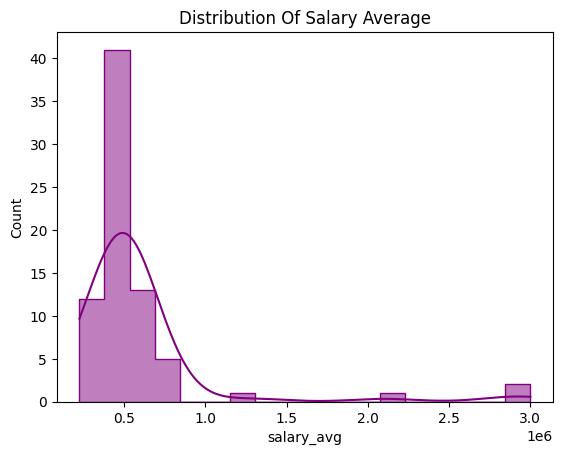

In [17]:
# Salary Distribution
sns.histplot(
    df['salary_avg'], 
    kde = True,
    color='purple',
    element='step'
)
plt.title('Distribution Of Salary Average')
plt.show()

In [71]:
df.columns

Index(['Job Title', 'Company Name', 'Location', 'Experience Required',
       'Salary', 'Skills Required', 'Job Description', 'Posted Date',
       'Scrape Date', 'Job Link', 'Source Platform', 'Standardized_Job_Title',
       'days_sinced_posted', 'salary_min', 'salary_max', 'salary_avg',
       'Salary_Band'],
      dtype='object')

In [73]:
df.groupby("Experience Required")["salary_avg"].median()

Experience Required
1 year(s)                  407500.0
4 year(s)                 3000000.0
6 year(s)                 2850000.0
8 year(s)                 2100000.0
No experience required     530000.0
Name: salary_avg, dtype: float64

“Salary distribution is highly concentrated between ₹4.5–5.5 LPA, indicating a strong entry-level market. A few high-paying outliers (up to ₹30 LPA) significantly increase the mean, suggesting the presence of senior or niche roles.”

<Axes: ylabel='salary_avg'>

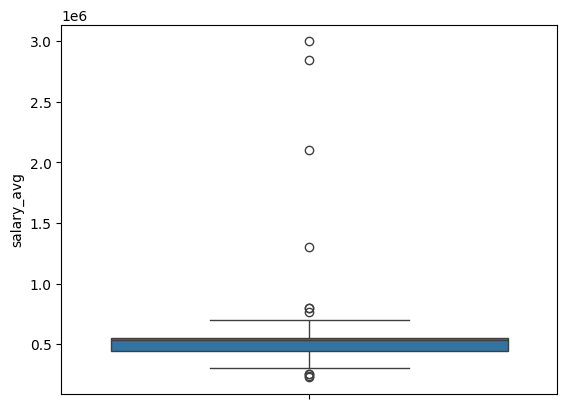

In [18]:
# Finding Outliers
sns.boxplot(
    df['salary_avg']
)

Outliers are normal here as some jobs are for freshers and some jobs are for experienced one.

In [21]:
df.columns

Index(['Job Title', 'Company Name', 'Location', 'Experience Required',
       'Salary', 'Skills Required', 'Job Description', 'Posted Date',
       'Scrape Date', 'Job Link', 'Source Platform', 'Standardized_Job_Title',
       'days_sinced_posted', 'salary_min', 'salary_max', 'salary_avg'],
      dtype='object')

In [22]:
salary_job_role = df.groupby('Standardized_Job_Title')['salary_avg'].median().sort_values(ascending=False)

In [23]:
salary_job_role

Standardized_Job_Title
Data Engineer                1668000.0
Data Scientist               1300000.0
Analytics                     550000.0
Other                         550000.0
Data Analyst                  530000.0
Machine Learning Engineer     500000.0
Business Analyst              390000.0
Name: salary_avg, dtype: float64

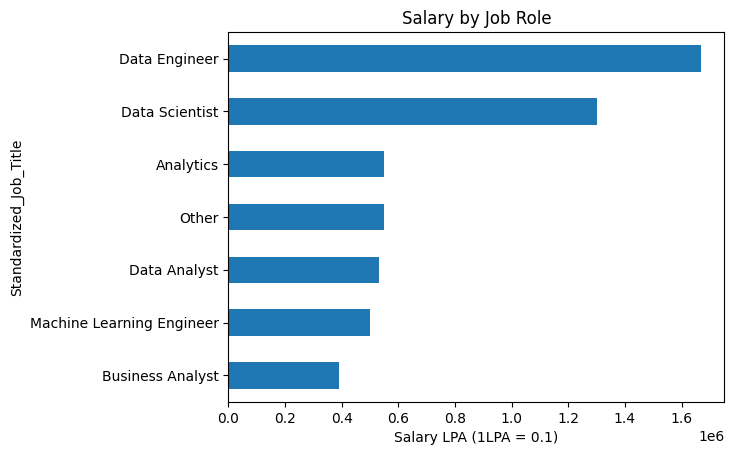

In [30]:
# bar plot for job_role vs salary
salary_job_role.sort_values().plot(kind='barh')
plt.xlabel('Salary LPA (1LPA = 0.1)')
plt.title('Salary by Job Role')
plt.show()

“The data reveals a sharp salary progression from analytics roles (~₹5 LPA) to engineering and data science roles (~₹13–16 LPA), highlighting the strong financial incentive to transition into advanced technical domains.”

In [36]:
location_mapping = {
    "Work from home": "Remote",
    "Nanakramguda": "Hyderabad",
    "Yalahanka": "Bangalore",
    "Gurgaon": "Gurgaon",
    "Noida": "Noida",
    "Maharashtra": "Maharashtra",
    "Telangana": "Telangana"
}
df["Location"] = df["Location"].replace(location_mapping)

In [37]:
salary_location = (df.groupby('Location')
                   ['salary_avg'].median()
                   .sort_values(ascending=False))

In [38]:
salary_location

Location
Noida        2850000.0
Ahmedabad     568000.0
Bangalore     550000.0
Remote        530000.0
Nashik        500000.0
Bhadrak       442500.0
Delhi         420000.0
Mumbai        415000.0
Pune          400000.0
Thane         350000.0
Gurgaon       340000.0
Kolkata       300000.0
Hyderabad     240000.0
Name: salary_avg, dtype: float64

In [74]:
df.groupby("Location")["salary_avg"].count()

Location
Ahmedabad     2
Bangalore    10
Bhadrak       1
Delhi         5
Gurgaon       4
Hyderabad     1
Kolkata       1
Mumbai        1
Nashik        1
Noida         3
Pune          1
Remote       44
Thane         1
Name: salary_avg, dtype: int64

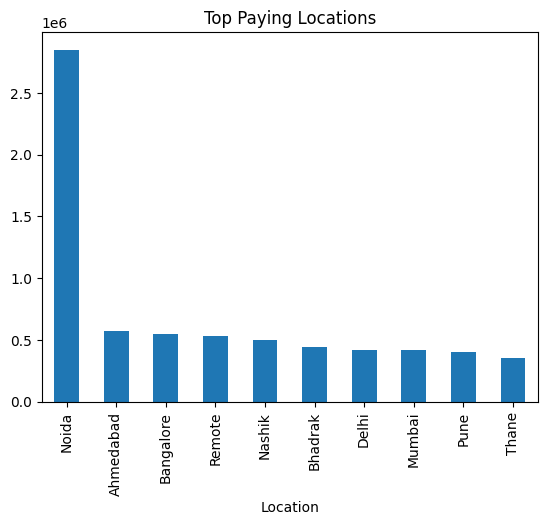

In [39]:
salary_location.head(10).plot(kind="bar")
plt.title("Top Paying Locations")
plt.show()

In [76]:
valid_locations = ["Remote", "Bangalore", "Delhi", "Gurgaon", "Noida"]

filtered_location_df = df[df["Location"].isin(valid_locations)]
filtered_location_df.groupby("Location")["salary_avg"].median()

Location
Bangalore     550000.0
Delhi         420000.0
Gurgaon       340000.0
Noida        2850000.0
Remote        530000.0
Name: salary_avg, dtype: float64

,Job Title,Company Name,Location,Experience Required,Salary,Skills Required,Job Description,Posted Date,Scrape Date,Job Link,Source Platform,Standardized_Job_Title,days_sinced_posted,salary_min,salary_max,salary_avg,Salary_Band
0,Punjabi-Speaking Online Data Analyst,"TELUS International AI Inc. (Las Vegas, United...",Remote,No experience required,"₹ 4,50,000 - 4,60,000","['English Proficiency (Spoken)', 'English Prof...",Are you a detail-oriented individual with a pa...,6 days ago,2026-04-28,https://internshala.com/job/detail/fresher-rem...,Internshala,Data Analyst,6.0,450000.0,460000.0,455000.0,Mid
1,Malayalam Language Data Analyst For Online,"TELUS International AI Inc. (Las Vegas, United...",Remote,No experience required,"₹ 4,50,000 - 4,60,000",['Data Analytics'],A Day in the Life of an Online Data Analyst: I...,3 weeks ago,2026-04-28,https://internshala.com/job/detail/fresher-rem...,Internshala,Data Analyst,21.0,450000.0,460000.0,455000.0,Mid
2,Online Data Analyst – Marathi Speaker,"TELUS International AI Inc. (Las Vegas, United...",Remote,No experience required,"₹ 4,50,000 - 4,60,000",['Data Analytics'],Are you a detail-oriented individual with a pa...,3 weeks ago,2026-04-28,https://internshala.com/job/detail/fresher-rem...,Internshala,Data Analyst,21.0,450000.0,460000.0,455000.0,Mid
3,Online Data Analyst - Gujarati Language,"TELUS International AI Inc. (Las Vegas, United...",Remote,No experience required,"₹ 4,50,000 - 4,60,000",['Data Analysis'],A Day in the Life of an Online Data Analyst:\r...,3 weeks ago,2026-04-28,https://internshala.com/job/detail/fresher-rem...,Internshala,Data Analyst,21.0,450000.0,460000.0,455000.0,Mid
4,Remote Online Data Analyst (Urdu-Speaking),"TELUS International AI Inc. (Las Vegas, United...",Remote,No experience required,"₹ 4,50,000 - 4,60,000","['Urdu Proficiency(Spoken)', 'Urdu Proficiency...",Key Responsibilities: \r\n\r\n1. Work on a pro...,3 weeks ago,2026-04-28,https://internshala.com/job/detail/fresher-rem...,Internshala,Data Analyst,21.0,450000.0,460000.0,455000.0,Mid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,Junior Machine Learning Specialist,Warewe Consultancy Private Limited,Gurgaon,1 year(s),"₹ 3,00,000 - 3,60,000","['Python', 'Django', 'Machine Learning', 'Neur...",Key responsibilities:\r\n\r\n1. Collect and pr...,Just now,2026-04-28,https://internshala.com/job/detail/junior-mach...,Internshala,Machine Learning Engineer,NaN,300000.0,360000.0,330000.0,Low
69,Business Analyst,THIS IS IT ARAMBOL LLP,Remote,1 year(s),"₹ 2,40,000 - 3,60,000","['Data Analytics', 'MS-Excel', 'English Profic...",Key Responsibilities: \r\n\r\n1. Conduct struc...,Few hours ago,2026-04-28,https://internshala.com/job/detail/remote-busi...,Internshala,Business Analyst,0.0,240000.0,360000.0,300000.0,Low
72,Data Analytics Executive,Growify Digital,Delhi,1 year(s),"₹ 2,00,000 - 3,00,000","['Data Analytics', 'MS-Excel']",Key responsibilities:\r\n\r\n1. Generating acc...,6 days ago,2026-04-28,https://internshala.com/job/detail/data-analyt...,Internshala,Analytics,6.0,200000.0,300000.0,250000.0,Low
73,Data Analyst,Avadeti Media (Part Of Ojas Group),Delhi,1 year(s),"₹ 2,00,000 - 3,00,000","['Python', 'SQL', 'Statistical Modeling', 'Bus...",We're Avadeti Media- the narrative intelligenc...,3 weeks ago,2026-04-28,https://internshala.com/job/detail/data-analys...,Internshala,Data Analyst,21.0,200000.0,300000.0,250000.0,Low


In [40]:
remote_salary = df[df["Location"] == "Remote"]["salary_avg"].median()
onsite_salary = df[df["Location"] != "Remote"]["salary_avg"].median()

In [41]:
print(remote_salary , onsite_salary)

530000.0 442500.0


In [42]:
skill_df = pd.read_csv(r"d:\Startup\Project\ai-career-coach\data\processed\jobs_with_skills.csv")

In [44]:
skill_df.columns

Index(['Job Title', 'Company Name', 'Location', 'Experience Required',
       'Salary', 'Skills Required', 'Job Description', 'Posted Date',
       'Scrape Date', 'Job Link', 'Source Platform', 'Standardized_Job_Title',
       'days_sinced_posted', 'salary_min', 'salary_max', 'salary_avg',
       'Experience_Years', 'combined_text', 'tokens', 'filtered_tokens',
       'lemmatized_tokens', 'processed_text', 'extracted_skills',
       'skill_count', 'technical_skills', 'soft_skills', 'business_skills'],
      dtype='object')

In [50]:
premium_skills_list = [
    'tensorflow', 'pytorch', 'nlp', 'llm', 'artificial intelligence',
    'computer vision', 'spark', 'hadoop', 'airflow', 'dbt',
    'databricks', 'snowflake', 'big data',
    'aws', 'azure', 'gcp',
    'scala', 'java'
]
premium_skills = {}

for skill in premium_skills_list:
    skill_jobs = skill_df[
        skill_df["extracted_skills"].str.contains(skill, na=False)
    ]
    
    premium_skills[skill] = skill_jobs["salary_avg"].dropna().median()

In [51]:
premium_skills

{'tensorflow': np.float64(330000.0),
 'pytorch': np.float64(330000.0),
 'nlp': np.float64(1215000.0),
 'llm': np.float64(2100000.0),
 'artificial intelligence': np.float64(477500.0),
 'computer vision': nan,
 'spark': nan,
 'hadoop': nan,
 'airflow': np.float64(2850000.0),
 'dbt': np.float64(336000.0),
 'databricks': nan,
 'snowflake': np.float64(2100000.0),
 'big data': np.float64(550000.0),
 'aws': np.float64(1218000.0),
 'azure': np.float64(336000.0),
 'gcp': nan,
 'scala': nan,
 'java': np.float64(471250.0)}

In [52]:
premium_skill_df = pd.DataFrame(
    premium_skills.items(),
    columns=["Skill", "Median_Salary"]
)

In [53]:
premium_skill_df.sort_values(
    by="Median_Salary",
    ascending=False
)

,Skill,Median_Salary
8,airflow,2850000.0
3,llm,2100000.0
11,snowflake,2100000.0
13,aws,1218000.0
2,nlp,1215000.0
12,big data,550000.0
4,artificial intelligence,477500.0
17,java,471250.0
9,dbt,336000.0
14,azure,336000.0


In [55]:
def salary_band(salary):
    if salary < 400000:
        return "Low"
    elif salary < 800000:
        return "Mid"
    else:
        return "High"

skill_df["Salary_Band"] = skill_df["salary_avg"].apply(
    lambda x: salary_band(x) if pd.notnull(x) else "Unknown"
)



In [ ]:
df["Salary_Band"] = df["salary_avg"].apply(
    lambda x: salary_band(x) if pd.notnull(x) else "Unknown"
)



In [65]:
skill_df = skill_df.dropna()
skill_df.shape

(74, 28)

In [66]:
df.shape

(75, 17)

In [ ]:
df.to_csv(
    r"d:\Startup\Project\ai-career-coach\data\processed\salary_enhanced.csv",
    index=False
)

In [68]:
premium_skill_df = premium_skill_df.dropna()

In [69]:
premium_skill_df

,Skill,Median_Salary
0,tensorflow,330000.0
1,pytorch,330000.0
2,nlp,1215000.0
3,llm,2100000.0
4,artificial intelligence,477500.0
8,airflow,2850000.0
9,dbt,336000.0
11,snowflake,2100000.0
12,big data,550000.0
13,aws,1218000.0


In [ ]:
premium_skill_df.to_csv(
     r"d:\Startup\Project\ai-career-coach\data\processed\premiun_skill_salary.csv",
    index=False
)

In [ ]:
filtered_location_df.to_csv(
    r"d:\Startup\Project\ai-career-coach\data\processed\filtered_location_df.csv",
    index=False
)